In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load the data
config = pd.read_csv('experiments/models/dataset_quality/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_quality.csv')

In [5]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [6]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [7]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

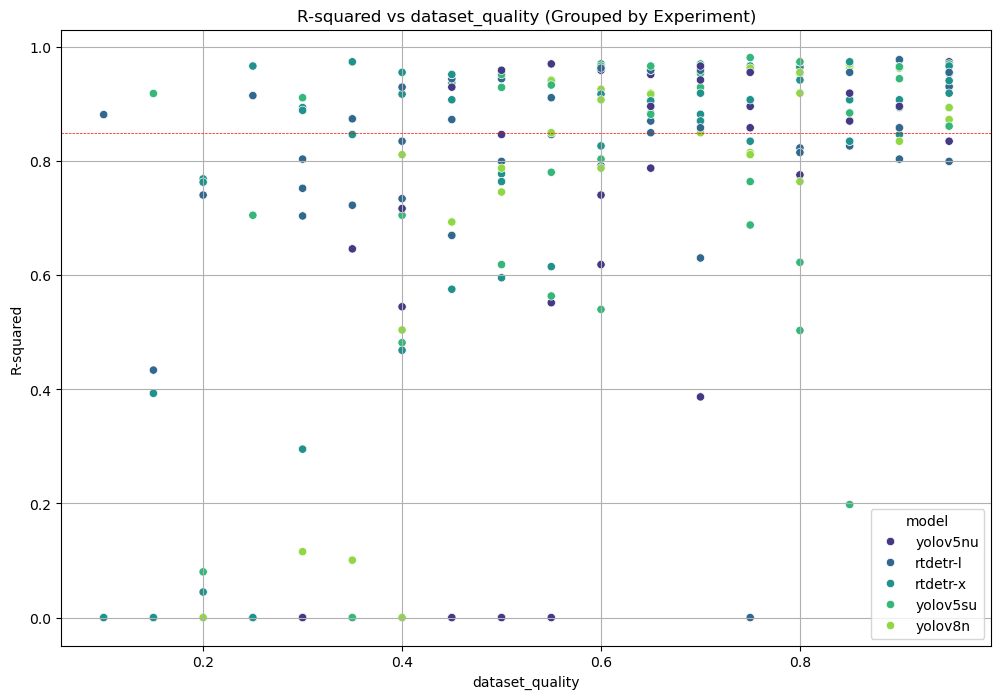

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
#filtered_df = df[df['model'] == 'yolov5su']
# Drop rows with NaN values in 'r_squared'
filtered_df = df.dropna(subset=['r_squared'])# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_df, x='dataset_quality', y='r_squared', hue='model', palette='viridis')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('dataset_quality')
plt.ylabel('R-squared')
plt.title('R-squared vs dataset_quality (Grouped by Experiment)')
plt.grid(True)

plt.show()

In [9]:
df['model'].unique()

array(['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'],
      dtype=object)

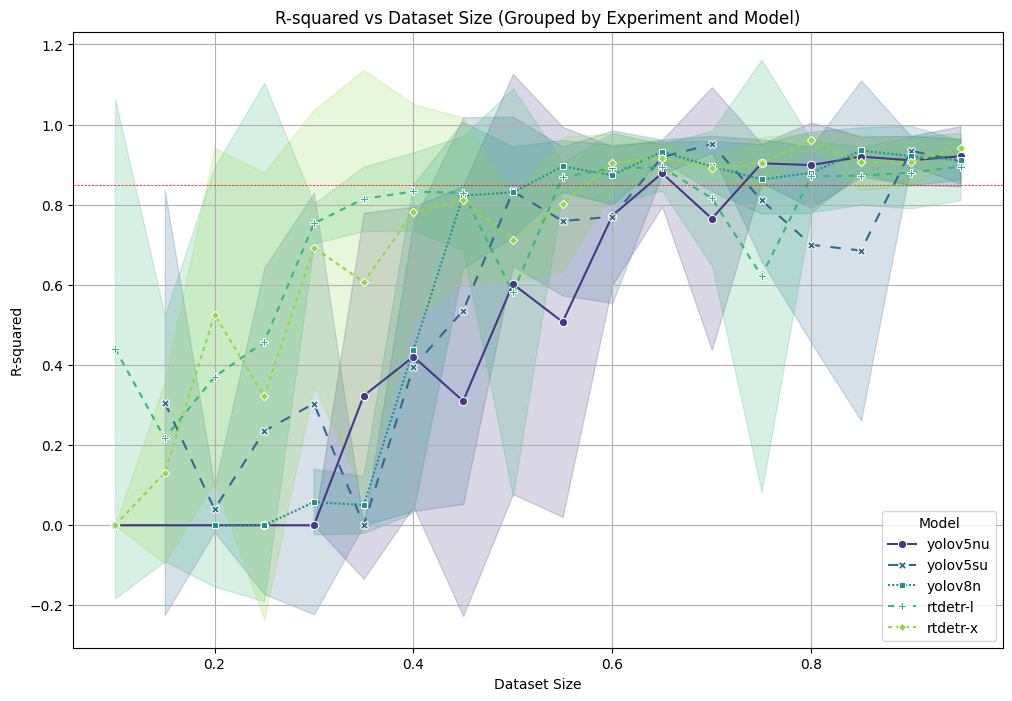

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])# Group by 'experiment' and select the observation with the highest R-squared value

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5nu': '', 'yolov5su': (5, 5), 'yolov8n': (1, 1), 'rtdetr-l': (3, 3), 'rtdetr-x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df, 
             errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, 
             hue_order=['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'], 
             style_order=['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model],
/tmp/ipykernel_63154/4154497033.py:26: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=

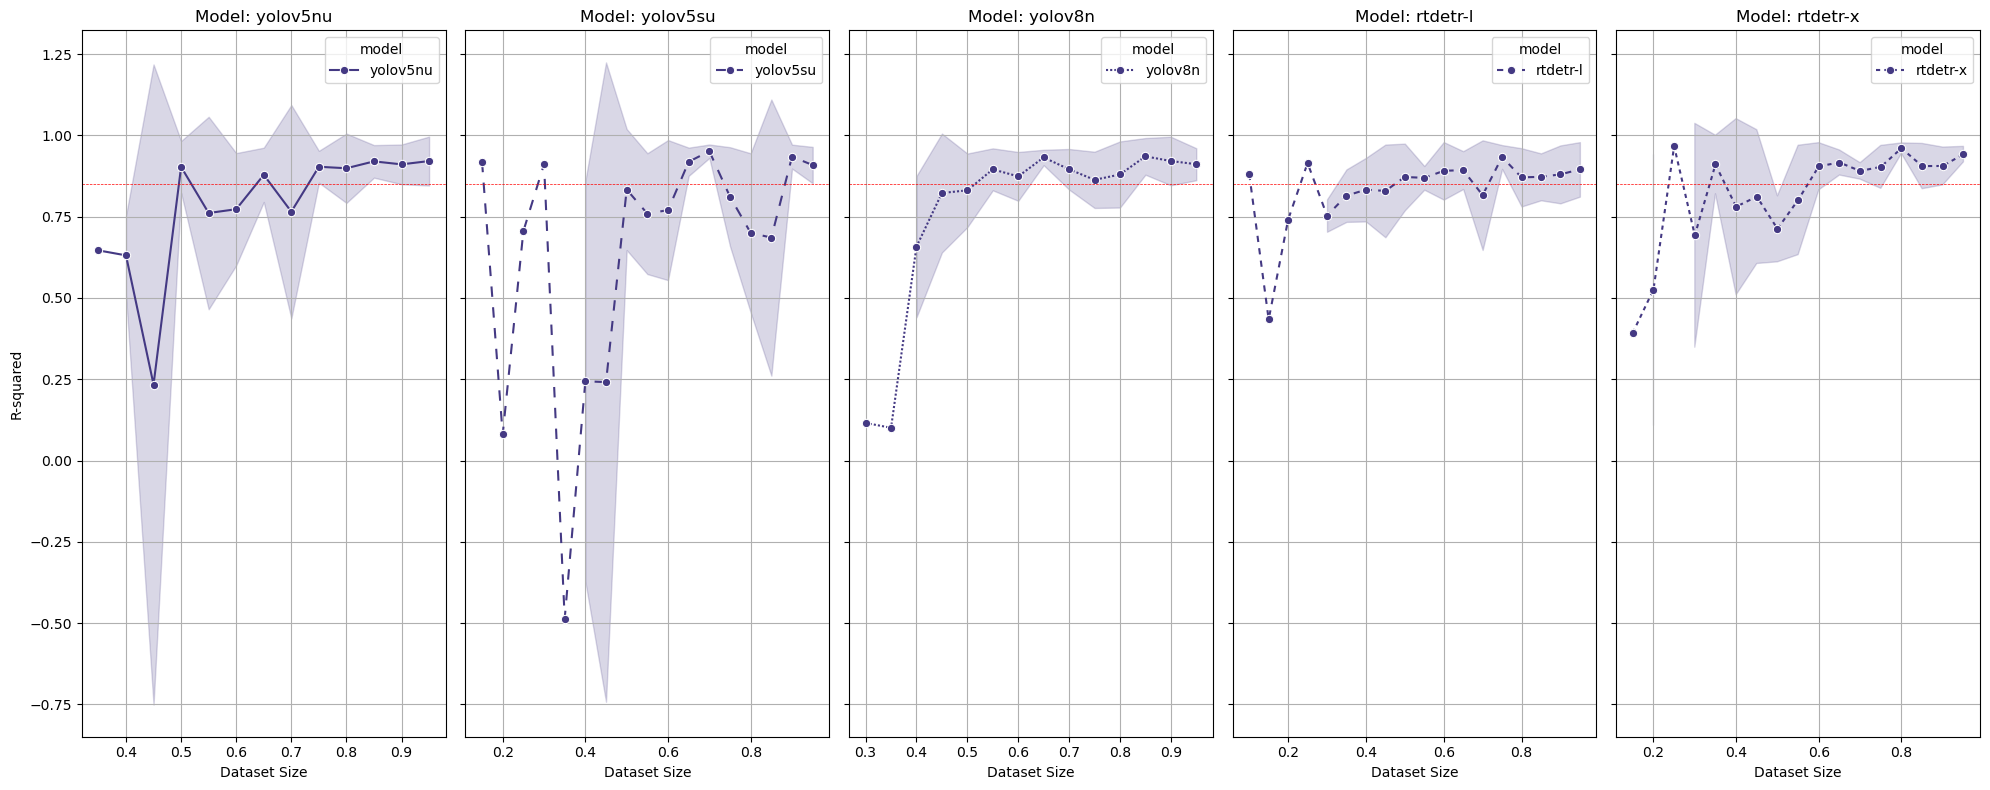

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.dropna(subset=['r_squared'])

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5nu': '', 'yolov5su': (5, 5), 'yolov8n': (1, 1), 'rtdetr-l': (3, 3), 'rtdetr-x': (2, 2)}  # Update dashes to have 5 styles

# Create subplots
models = ['yolov5nu', 'yolov5su', 'yolov8n', 'rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    sns.lineplot(x='dataset_quality', y='r_squared', hue='model', style='model', data=filtered_df[filtered_df['model'] == model], 
                 errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, 
                 hue_order=[model], style_order=[model], ax=ax)
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('R-squared')
    ax.grid(True)

plt.tight_layout()
plt.show()